# EDA on <b><u>application_record.csv</b></u> & <b><u>credit_record.csv</b></u>

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nbformat as nbf
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from scipy import stats


FIG_DIR = "./eda_figures" #Configure output folders
os.makedirs(FIG_DIR, exist_ok=True)

APP_PATH = "application_record.csv"
CREDIT_PATH = "credit_record.csv"


app = pd.read_csv(APP_PATH)
credit = pd.read_csv(CREDIT_PATH)

print("application_record shape:", app.shape)
print("credit_record shape:", credit.shape)


display(app.head())
display(credit.head())

print("Missing values in application_record:")
display(app.isnull().sum().sort_values(ascending=False).head(30))

print("Missing values in credit_record:")
display(credit.isnull().sum().sort_values(ascending=False))

application_record shape: (438557, 18)
credit_record shape: (1048575, 3)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


Missing values in application_record:


OCCUPATION_TYPE        134203
ID                          0
CODE_GENDER                 0
FLAG_EMAIL                  0
FLAG_PHONE                  0
FLAG_WORK_PHONE             0
FLAG_MOBIL                  0
DAYS_EMPLOYED               0
DAYS_BIRTH                  0
NAME_HOUSING_TYPE           0
NAME_FAMILY_STATUS          0
NAME_EDUCATION_TYPE         0
NAME_INCOME_TYPE            0
AMT_INCOME_TOTAL            0
CNT_CHILDREN                0
FLAG_OWN_REALTY             0
FLAG_OWN_CAR                0
CNT_FAM_MEMBERS             0
dtype: int64

Missing values in credit_record:


ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64

In [2]:
#Map credit STATUS to numeric and aggregate by ID
def map_status(s):
    if s in ["X", "C"]:
        return 0
    try:
        return int(s)
    except:
        return np.nan

credit["STATUS_NUM"] = credit["STATUS"].apply(map_status)
credit["is_delinq"] = credit["STATUS_NUM"].apply(lambda x: 1 if (not pd.isna(x) and x >= 1) else 0)

#Aggregate features per ID
credit_agg = credit.groupby("ID").agg(
    months_observed = ("MONTHS_BALANCE","count"),
    max_status = ("STATUS_NUM","max"),
    mean_status = ("STATUS_NUM","mean"),
    med_status = ("STATUS_NUM","median"),
    count_delinq = ("is_delinq","sum"),
    last_month = ("MONTHS_BALANCE","min"),
    first_month = ("MONTHS_BALANCE","max")
).reset_index()

credit_agg["pct_delinq"] = credit_agg["count_delinq"] / credit_agg["months_observed"]
credit_agg["ever_delinq"] = (credit_agg["max_status"] >= 1).astype(int)

print("Aggregated credit features :")
display(credit_agg.head())

Aggregated credit features :


,ID,months_observed,max_status,mean_status,med_status,count_delinq,last_month,first_month,pct_delinq,ever_delinq
0,5001711,4,0,0.0,0.0,0,-3,0,0.0,0
1,5001712,19,0,0.0,0.0,0,-18,0,0.0,0
2,5001713,22,0,0.0,0.0,0,-21,0,0.0,0
3,5001714,15,0,0.0,0.0,0,-14,0,0.0,0
4,5001715,60,0,0.0,0.0,0,-59,0,0.0,0


In [3]:
#Merge aggregated credit features into application data
df = app.merge(credit_agg, on="ID", how="left")

#Fill NA for clients with no credit records
df["months_observed"] = df["months_observed"].fillna(0).astype(int)
df["max_status"] = df["max_status"].fillna(0)
df["mean_status"] = df["mean_status"].fillna(0)
df["med_status"] = df["med_status"].fillna(0)
df["count_delinq"] = df["count_delinq"].fillna(0).astype(int)
df["pct_delinq"] = df["pct_delinq"].fillna(0.0)
df["ever_delinq"] = df["ever_delinq"].fillna(0).astype(int)

#Derived features
df["AGE_YEARS"] = (-df["DAYS_BIRTH"] / 365).astype(int)
#Replace the sentinel 365243 in DAYS_EMPLOYED with NaN
df["DAYS_EMPLOYED_REPLACED"] = df["DAYS_EMPLOYED"].replace({365243: np.nan})
df["EMPLOYED_YEARS"] = (-df["DAYS_EMPLOYED_REPLACED"] / 365).round(1)

print("Merged shape:", df.shape)
display(df.head())

Merged shape: (438557, 30)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,mean_status,med_status,count_delinq,last_month,first_month,pct_delinq,ever_delinq,AGE_YEARS,DAYS_EMPLOYED_REPLACED,EMPLOYED_YEARS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,0.062500,0.0,1,-15.0,0.0,0.062500,1,32,-4542.0,12.4
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,0.066667,0.0,1,-14.0,0.0,0.066667,1,32,-4542.0,12.4
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,0.000000,0.0,0,-29.0,0.0,0.000000,0,58,-1134.0,3.1
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,0.000000,0.0,0,-4.0,0.0,0.000000,0,52,-3051.0,8.4
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,0.000000,0.0,0,-26.0,-22.0,0.000000,0,52,-3051.0,8.4


Saved: ./eda_figures/income_raw.png


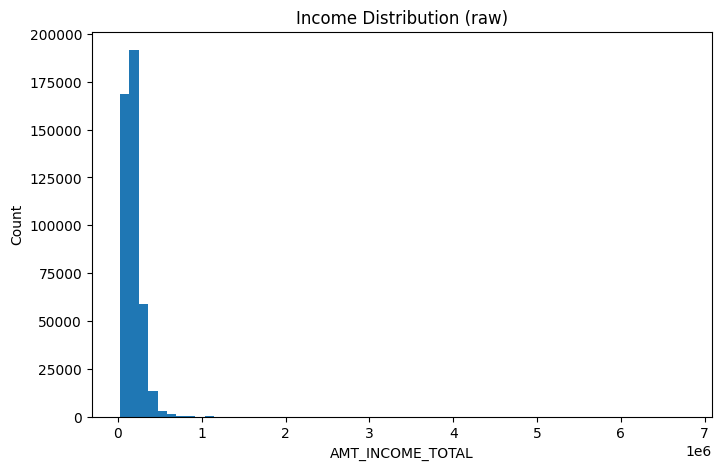

Saved: ./eda_figures/income_log.png


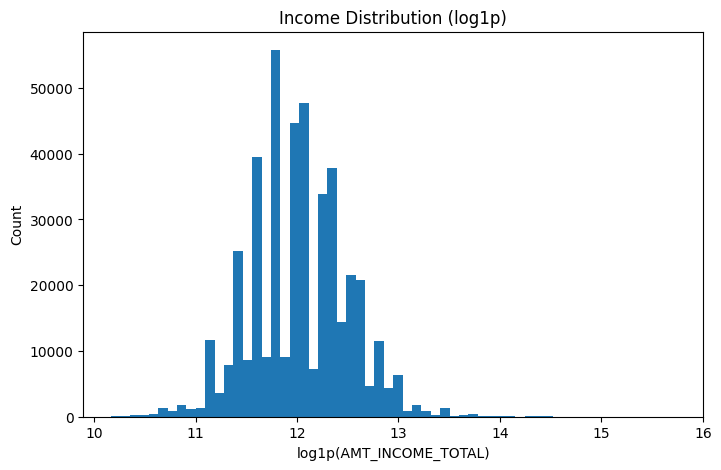

Saved: ./eda_figures/age_dist.png


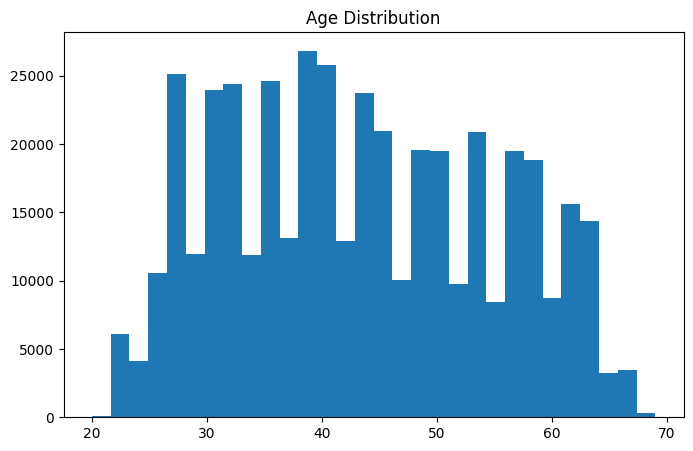

Saved: ./eda_figures/employed_years.png


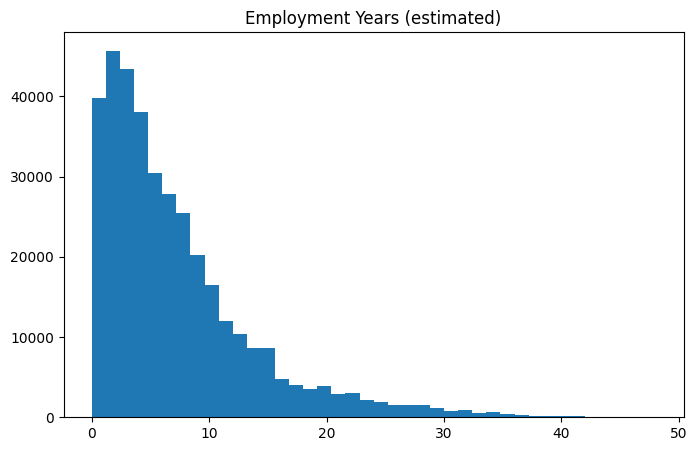

In [4]:
#Utility to save plots
def save_fig(fig, filename):
    path = os.path.join(FIG_DIR, filename)
    fig.savefig(path, bbox_inches="tight")
    print("Saved:", path)

#1 Income distribution: raw and log
fig = plt.figure(figsize=(8,5))
plt.hist(df["AMT_INCOME_TOTAL"].dropna(), bins=60)
plt.title("Income Distribution (raw)")
plt.xlabel("AMT_INCOME_TOTAL")
plt.ylabel("Count")
save_fig(fig, "income_raw.png")
plt.show()

fig = plt.figure(figsize=(8,5))
plt.hist(np.log1p(df["AMT_INCOME_TOTAL"].dropna()), bins=60)
plt.title("Income Distribution (log1p)")
plt.xlabel("log1p(AMT_INCOME_TOTAL)")
plt.ylabel("Count")
save_fig(fig, "income_log.png")
plt.show()

#2 Age distribution
fig = plt.figure(figsize=(8,5))
plt.hist(df["AGE_YEARS"].dropna(), bins=30)
plt.title("Age Distribution")
save_fig(fig, "age_dist.png")
plt.show()

#3 Employment years distribution
fig = plt.figure(figsize=(8,5))
plt.hist(df["EMPLOYED_YEARS"].dropna(), bins=40)
plt.title("Employment Years (estimated)")
save_fig(fig, "employed_years.png")
plt.show()

Saved: ./eda_figures/gender_counts.png


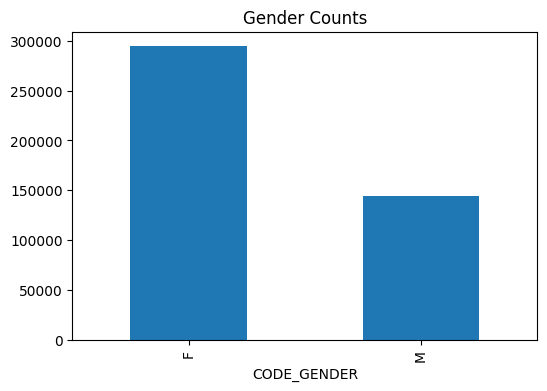

Saved: ./eda_figures/education_counts.png


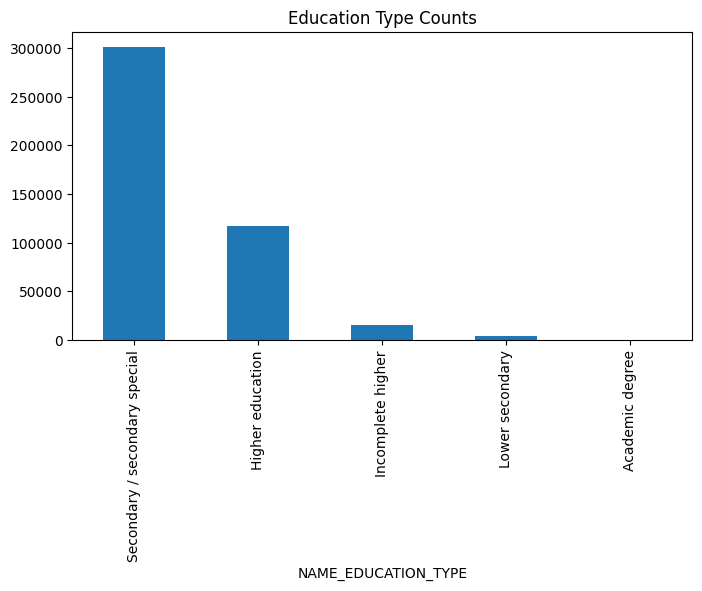

Saved: ./eda_figures/income_type_counts.png


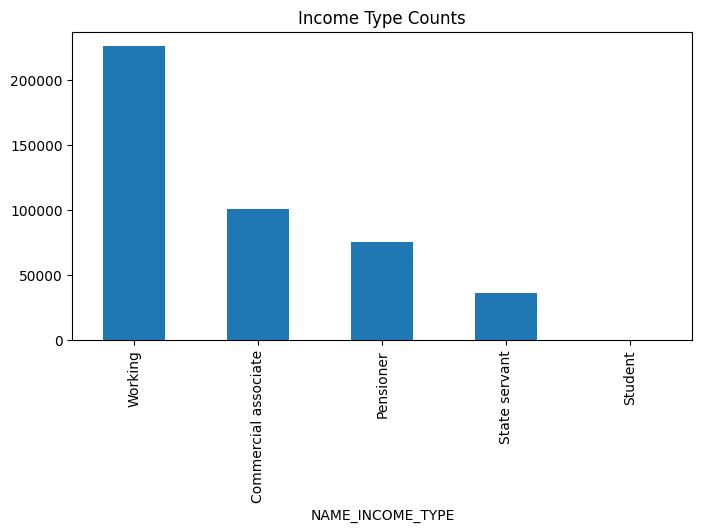

Saved: ./eda_figures/housing_counts.png


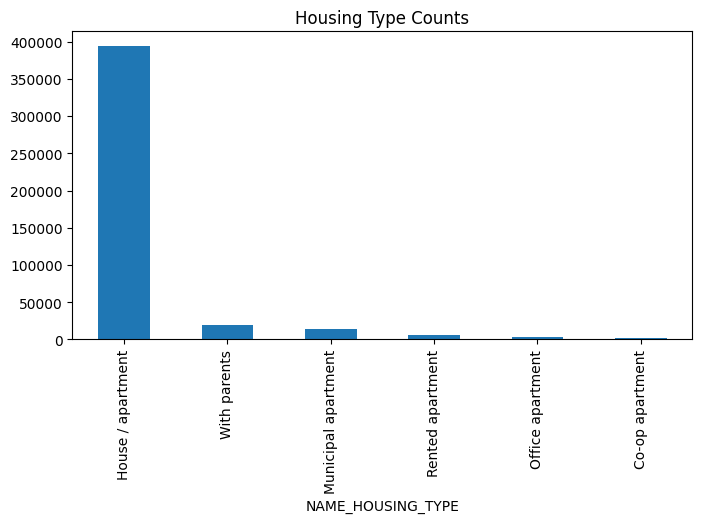

Saved: ./eda_figures/occupation_top20.png


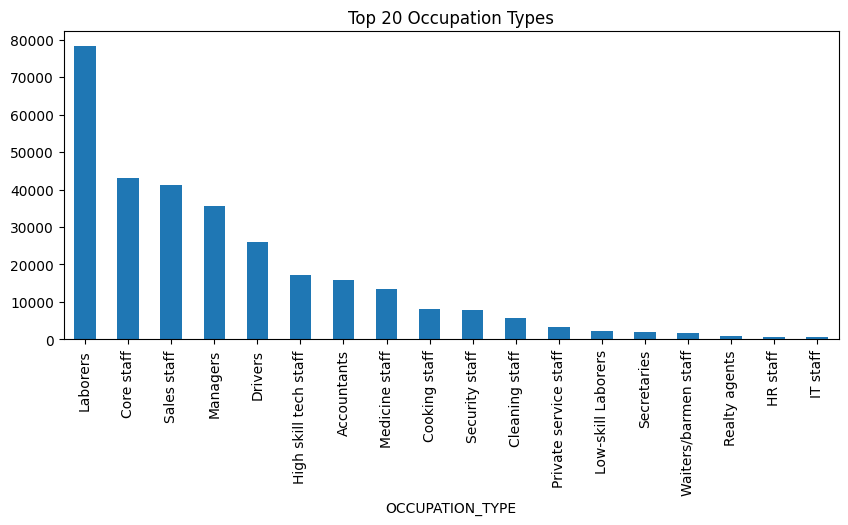

In [5]:
#Categorical counts: gender, education, income type, housing, occupation top 20
fig = plt.figure(figsize=(6,4))
df["CODE_GENDER"].value_counts().plot(kind="bar")
plt.title("Gender Counts")
save_fig(fig, "gender_counts.png")
plt.show()

fig = plt.figure(figsize=(8,4))
df["NAME_EDUCATION_TYPE"].value_counts().plot(kind="bar")
plt.title("Education Type Counts")
save_fig(fig, "education_counts.png")
plt.show()

fig = plt.figure(figsize=(8,4))
df["NAME_INCOME_TYPE"].value_counts().plot(kind="bar")
plt.title("Income Type Counts")
save_fig(fig, "income_type_counts.png")
plt.show()

fig = plt.figure(figsize=(8,4))
df["NAME_HOUSING_TYPE"].value_counts().plot(kind="bar")
plt.title("Housing Type Counts")
save_fig(fig, "housing_counts.png")
plt.show()

fig = plt.figure(figsize=(10,4))
df["OCCUPATION_TYPE"].value_counts().nlargest(20).plot(kind="bar")
plt.title("Top 20 Occupation Types")
save_fig(fig, "occupation_top20.png")
plt.show()

Saved: ./eda_figures/credit_status_counts.png


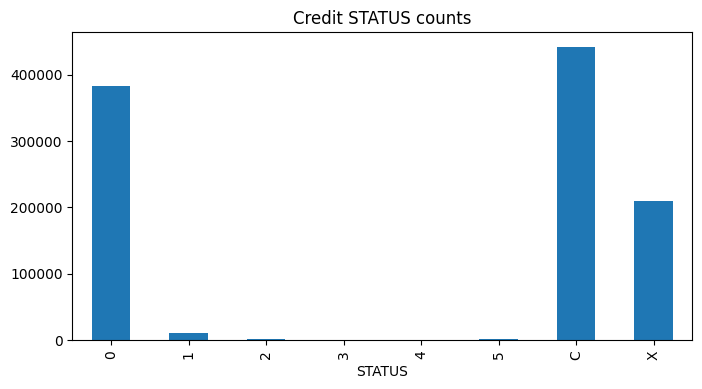

Saved: ./eda_figures/avg_status_by_month.png


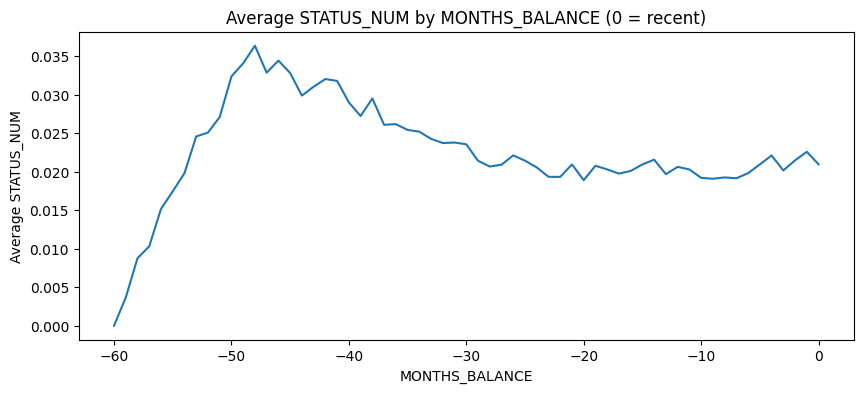

STATUS,0,1,2,3,4,5,C,X
MONTHS_BALANCE,,,,,,,,
0,8914,309,19,6,5,65,17613,6925
-1,10301,372,17,6,11,62,17504,6163
-2,10398,367,19,11,3,57,17139,6215
-3,10610,313,31,6,5,54,16784,6051
-4,10491,379,21,5,8,54,16403,6004
-5,10568,316,20,9,9,54,16015,5890
-6,10279,309,19,7,8,48,15630,5996
-7,10062,305,15,9,6,44,15220,5979
-8,9752,300,24,7,4,42,14811,5944


In [6]:
#Credit record analysis: status distribution and trend by MONTHS_BALANCE
fig = plt.figure(figsize=(8,4))
credit["STATUS"].value_counts().sort_index().plot(kind="bar")
plt.title("Credit STATUS counts")
save_fig(fig, "credit_status_counts.png")
plt.show()

#Average STATUS_NUM by MONTHS_BALANCE (time trend)
pivot = credit.groupby("MONTHS_BALANCE")["STATUS_NUM"].mean().reset_index().sort_values("MONTHS_BALANCE", ascending=False)
fig = plt.figure(figsize=(10,4))
plt.plot(pivot["MONTHS_BALANCE"], pivot["STATUS_NUM"])
plt.title("Average STATUS_NUM by MONTHS_BALANCE (0 = recent)")
plt.xlabel("MONTHS_BALANCE")
plt.ylabel("Average STATUS_NUM")
save_fig(fig, "avg_status_by_month.png")
plt.show()


status_counts_by_month = credit.pivot_table(index="MONTHS_BALANCE", columns="STATUS", values="ID", aggfunc="count", fill_value=0)
display(status_counts_by_month.sort_index(ascending=False).head(24))

Saved: ./eda_figures/corr_matrix.png


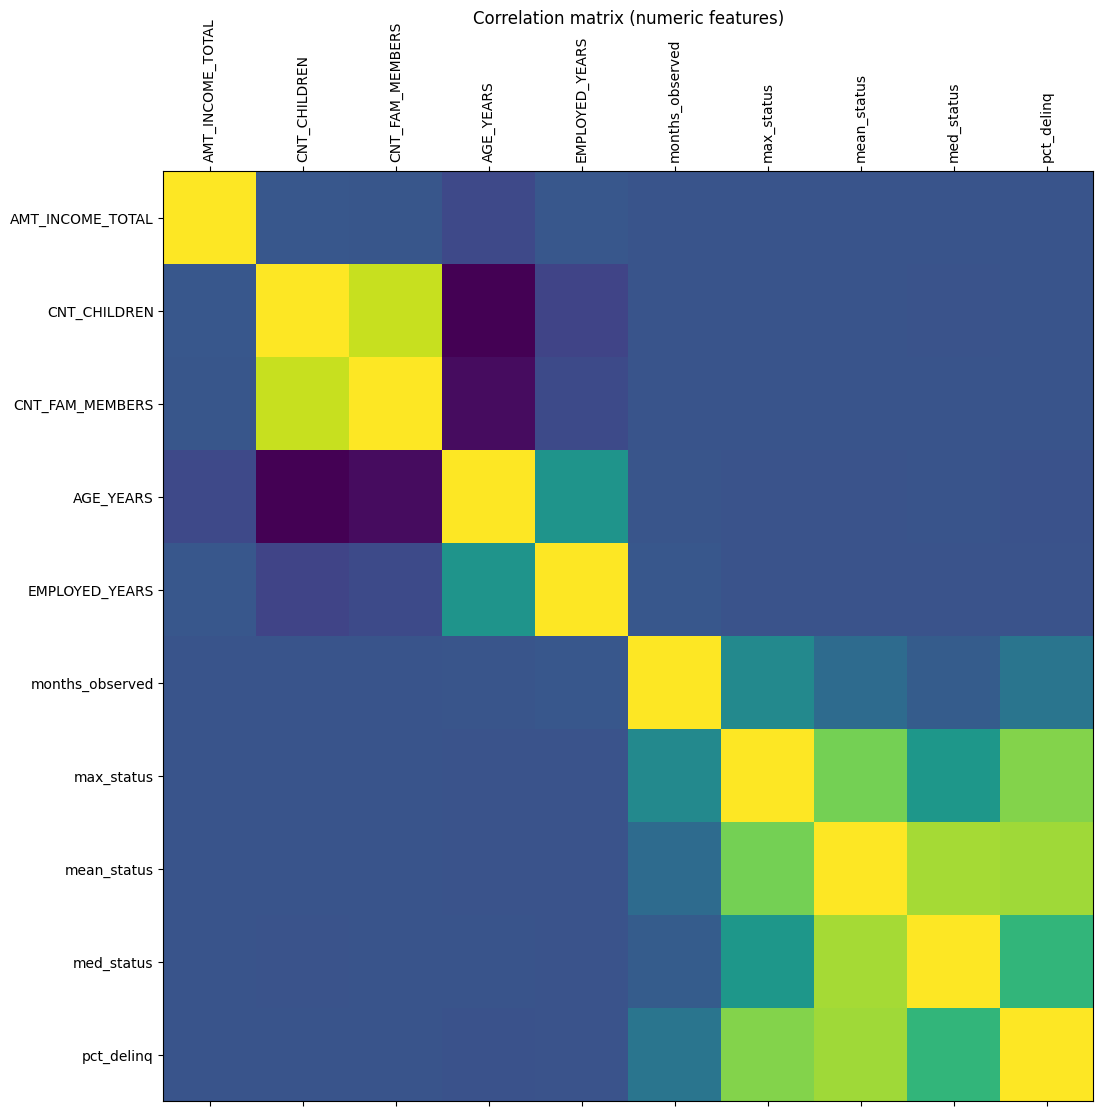

,AMT_INCOME_TOTAL,CNT_CHILDREN,CNT_FAM_MEMBERS,AGE_YEARS,EMPLOYED_YEARS,months_observed,max_status,mean_status,med_status,pct_delinq
AMT_INCOME_TOTAL,1.000,0.019,0.011,-0.054,0.020,0.002,0.004,0.004,0.002,0.002
CNT_CHILDREN,0.019,1.000,0.885,-0.349,-0.070,0.000,0.002,-0.000,-0.002,0.001
CNT_FAM_MEMBERS,0.011,0.885,1.000,-0.306,-0.044,0.004,0.001,-0.000,-0.001,0.001
AGE_YEARS,-0.054,-0.349,-0.306,1.000,0.348,0.007,-0.005,-0.003,0.000,-0.009
EMPLOYED_YEARS,0.020,-0.070,-0.044,0.348,1.000,0.016,-0.004,-0.006,-0.005,-0.005
months_observed,0.002,0.000,0.004,0.007,0.016,1.000,0.288,0.125,0.044,0.173
max_status,0.004,0.002,0.001,-0.005,-0.004,0.288,1.000,0.717,0.367,0.750
mean_status,0.004,-0.000,-0.000,-0.003,-0.006,0.125,0.717,1.000,0.819,0.808
med_status,0.002,-0.002,-0.001,0.000,-0.005,0.044,0.367,0.819,1.000,0.540
pct_delinq,0.002,0.001,0.001,-0.009,-0.005,0.173,0.750,0.808,0.540,1.000


In [7]:
#Correlation matrix
numeric_cols = [
    "AMT_INCOME_TOTAL", "CNT_CHILDREN", "CNT_FAM_MEMBERS",
    "AGE_YEARS", "EMPLOYED_YEARS", "months_observed",
    "max_status", "mean_status", "med_status", "pct_delinq"
]
num_df = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
corr = num_df.corr()

fig = plt.figure(figsize=(12,14))
plt.matshow(corr, fignum=1)
plt.title("Correlation matrix (numeric features)", y=1.15)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
save_fig(fig, "corr_matrix.png")
plt.show()

display(corr.round(3))

In [8]:
#Grouped analyses: default (ever_delinq) rates by groups
#Create bins for income and age
df["income_bin"] = pd.qcut(df["AMT_INCOME_TOTAL"].replace(0, np.nan).fillna(df["AMT_INCOME_TOTAL"].median()), q=6, duplicates="drop")
df["age_bin"] = pd.cut(df["AGE_YEARS"], bins=[18,25,35,45,55,65,100])

def group_default_rate(col, top_n=None):
    gp = df.groupby(col).agg(
        count=("ID","count"),
        ever_delinq_rate=("ever_delinq","mean"),
        mean_pct_delinq=("pct_delinq","mean"),
        mean_max_status=("max_status","mean")
    ).sort_values("count", ascending=False)
    if top_n:
        return gp.head(top_n)
    return gp

print("Default rate by gender:")
display(group_default_rate("CODE_GENDER"))
print("Default rate by education:")
display(group_default_rate("NAME_EDUCATION_TYPE"))
print("Default rate by income bin:")
display(group_default_rate("income_bin"))
print("Default rate by age bin:")
display(group_default_rate("age_bin"))
print("Default rate by housing:")
display(group_default_rate("NAME_HOUSING_TYPE"))
print("Default rate by income type:")
display(group_default_rate("NAME_INCOME_TYPE"))
print("Top occupations by count with default rates:")
display(group_default_rate("OCCUPATION_TYPE", top_n=20))

Default rate by gender:


,count,ever_delinq_rate,mean_pct_delinq,mean_max_status
CODE_GENDER,,,,
F,294440,0.009367,0.001198,0.012111
M,144117,0.010637,0.001504,0.014218


Default rate by education:


,count,ever_delinq_rate,mean_pct_delinq,mean_max_status
NAME_EDUCATION_TYPE,,,,
Secondary / secondary special,301821,0.009575,0.001255,0.012332
Higher education,117522,0.009768,0.001315,0.013053
Incomplete higher,14851,0.013938,0.001974,0.019056
Lower secondary,4051,0.009627,0.001647,0.017033
Academic degree,312,0.022436,0.000890,0.022436


Default rate by income bin:


...

,count,ever_delinq_rate,mean_pct_delinq,mean_max_status
NAME_HOUSING_TYPE,,,,
House / apartment,393831,0.009603,0.001275,0.012521
With parents,19077,0.011899,0.001611,0.014310
Municipal apartment,14214,0.010553,0.001388,0.016252
Rented apartment,5974,0.013391,0.001406,0.016907
Office apartment,3922,0.009689,0.001723,0.014023
Co-op apartment,1539,0.009097,0.001281,0.015595


Default rate by income type:


,count,ever_delinq_rate,mean_pct_delinq,mean_max_status
NAME_INCOME_TYPE,,,,
Working,226104,0.009646,0.001253,0.012379
Commercial associate,100757,0.010719,0.001524,0.014133
Pensioner,75493,0.008531,0.001149,0.012293
State servant,36186,0.010639,0.001270,0.012795
Student,17,0.058824,0.003922,0.058824


Top occupations by count with default rates:


,count,ever_delinq_rate,mean_pct_delinq,mean_max_status
OCCUPATION_TYPE,,,,
Laborers,78240,0.009330,0.001215,0.012078
Core staff,43007,0.010766,0.001454,0.015021
Sales staff,41098,0.009465,0.001204,0.011582
Managers,35487,0.010990,0.001487,0.013808
Drivers,26090,0.010119,0.001290,0.013300
High skill tech staff,17289,0.010469,0.001382,0.014229
Accountants,15985,0.009196,0.000972,0.011573
Medicine staff,13520,0.012056,0.001531,0.013979
Cooking staff,8076,0.010649,0.001739,0.013621


Saved: ./eda_figures/ever_delinq_by_gender.png


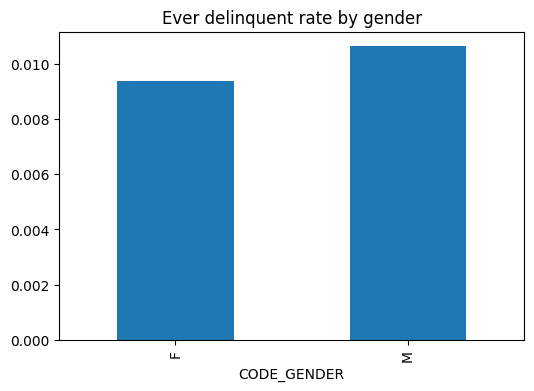

Saved: ./eda_figures/ever_delinq_by_income_bin.png


/var/folders/vv/f372vpgj7115wn1gcr1q6lx80000gn/T/ipykernel_20065/3959072304.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("income_bin")["ever_delinq"].mean().sort_index().plot(kind="bar")


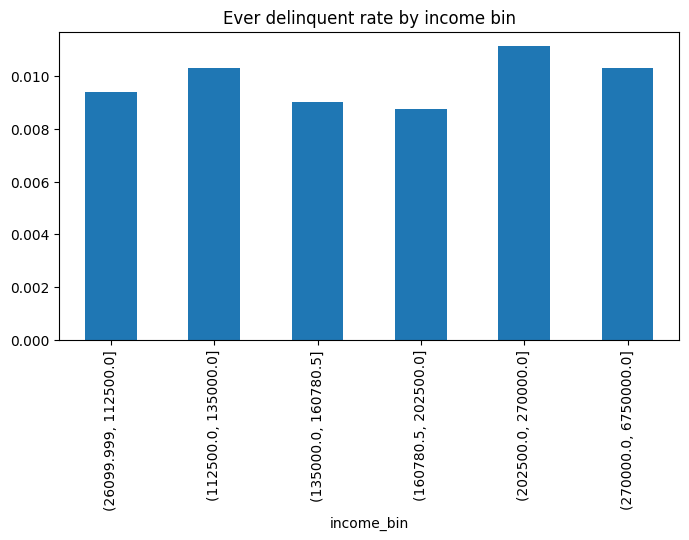

Saved: ./eda_figures/ever_delinq_by_age_bin.png


/var/folders/vv/f372vpgj7115wn1gcr1q6lx80000gn/T/ipykernel_20065/3959072304.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_bin")["ever_delinq"].mean().sort_index().plot(kind="bar")


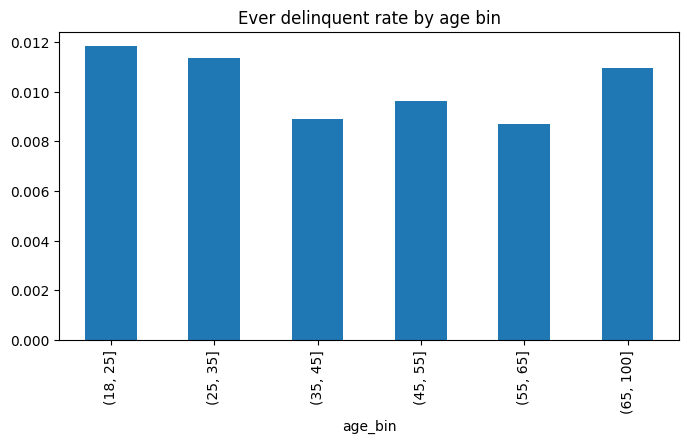

Saved: ./eda_figures/ever_delinq_by_education.png


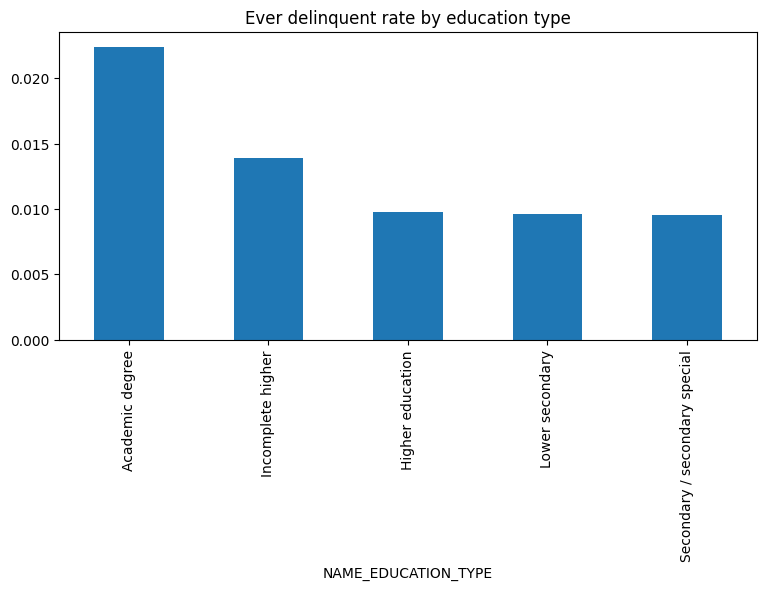

In [9]:
#Visualize default rate by some key categorical variables
fig = plt.figure(figsize=(6,4))
df.groupby("CODE_GENDER")["ever_delinq"].mean().plot(kind="bar")
plt.title("Ever delinquent rate by gender")
save_fig(fig, "ever_delinq_by_gender.png")
plt.show()

fig = plt.figure(figsize=(8,4))
df.groupby("income_bin")["ever_delinq"].mean().sort_index().plot(kind="bar")
plt.title("Ever delinquent rate by income bin")
save_fig(fig, "ever_delinq_by_income_bin.png")
plt.show()

fig = plt.figure(figsize=(8,4))
df.groupby("age_bin")["ever_delinq"].mean().sort_index().plot(kind="bar")
plt.title("Ever delinquent rate by age bin")
save_fig(fig, "ever_delinq_by_age_bin.png")
plt.show()

fig = plt.figure(figsize=(9,4))
df.groupby("NAME_EDUCATION_TYPE")["ever_delinq"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Ever delinquent rate by education type")
save_fig(fig, "ever_delinq_by_education.png")
plt.show()

In [10]:
#Simple univariate statistical separation tests for numeric features between classes
def class_stats(feature):
    a = df[df["ever_delinq"]==0][feature].dropna()
    b = df[df["ever_delinq"]==1][feature].dropna()
    try:
        t,p = stats.ttest_ind(a,b, equal_var=False, nan_policy="omit")
    except Exception:
        t,p = np.nan, np.nan
    return {
        "feature": feature,
        "mean_no_delinq": a.mean(),
        "mean_delinq": b.mean(),
        "t_stat": t,
        "p_value": p,
        "n_no": a.shape[0],
        "n_yes": b.shape[0]
    }

features_to_test = numeric_cols
stats_list = [class_stats(f) for f in features_to_test]
stats_df = pd.DataFrame(stats_list).sort_values("p_value")
display(stats_df)

,feature,mean_no_delinq,mean_delinq,t_stat,p_value,n_no,n_yes
5,months_observed,1.538562,25.534840,-105.192011,0.000000e+00,434266,4291
6,max_status,0.000000,1.308553,-94.852672,0.000000e+00,434266,4291
9,pct_delinq,0.000000,0.132745,-61.976797,0.000000e+00,434266,4291
7,mean_status,0.000000,0.196212,-30.767322,5.147425e-188,434266,4291
8,med_status,0.000000,0.068282,-9.581043,1.575551e-21,434266,4291
3,AGE_YEARS,43.336209,42.342811,5.611497,2.129752e-08,434266,4291
0,AMT_INCOME_TOTAL,187465.927400,193430.405733,-3.340759,8.425137e-04,434266,4291
1,CNT_CHILDREN,0.427130,0.453740,-2.160049,3.082324e-02,434266,4291
2,CNT_FAM_MEMBERS,2.194204,2.220928,-1.810065,7.035445e-02,434266,4291
4,EMPLOYED_YEARS,7.186736,7.167303,0.181078,8.563159e-01,359564,3664


In [11]:
#Save aggregated CSVs for modeling and quick access
credit_agg.to_csv("credit_agg_by_id.csv", index=False)
df.to_csv("merged_app_credit.csv", index=False)
print("Saved: credit_agg_by_id.csv and merged_app_credit.csv")
print("Figures saved in folder:", FIG_DIR)

Saved: credit_agg_by_id.csv and merged_app_credit.csv
Figures saved in folder: ./eda_figures


In [12]:
#df = merged dataset
#target column should be binary, e.g., "ever_delinq"

X = df.drop(columns=["ever_delinq"])
y = df["ever_delinq"]

#One-hot encode categorical features
X = pd.get_dummies(X, drop_first=True)

#Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)
rf.fit(X_train, y_train)

#Feature importances
importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print(importances.head(20))

                                  feature  importance
17                             pct_delinq    0.217591
14                           count_delinq    0.167059
12                            mean_status    0.149223
11                             max_status    0.135758
16                            first_month    0.094579
10                        months_observed    0.086855
0                                      ID    0.086105
15                             last_month    0.060560
13                             med_status    0.001096
18                              AGE_YEARS    0.000207
3                              DAYS_BIRTH    0.000164
20                         EMPLOYED_YEARS    0.000117
23                      FLAG_OWN_REALTY_Y    0.000107
19                 DAYS_EMPLOYED_REPLACED    0.000106
4                           DAYS_EMPLOYED    0.000075
2                        AMT_INCOME_TOTAL    0.000074
21                          CODE_GENDER_M    0.000034
64                       age

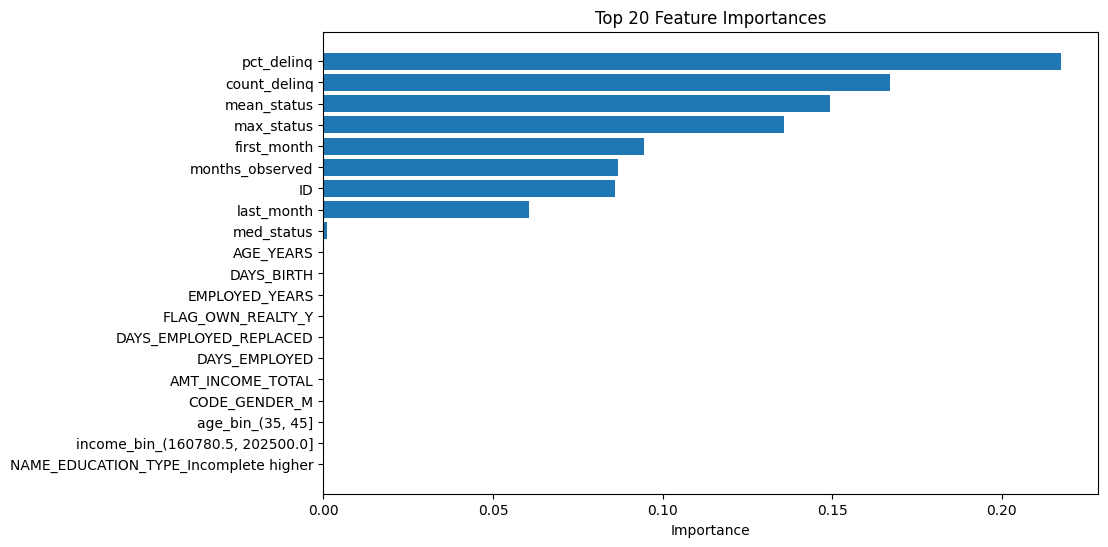

In [13]:
top = importances.head(20)

plt.figure(figsize=(10,6))
plt.barh(top["feature"], top["importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.show()

# Short summary / notes for modeling

#### Notebook produced:
- Aggregated credit features for each ID (credit_agg_by_id.csv)
  > months_observed, max_status, mean_status, med_status, count_delinq, pct_delinq, ever_delinq
- Merged application + credit features (merged_app_credit.csv)

#### Suggested target:
- 'ever_delinq' (binary) => whether a client ever had STATUS >= 1 in credit_record
  Notes: alternative targets can be:
  * fraction of delinquent months (pct_delinq)
  * max_status (multiclass severity)
  * last_seen_status (to model recent behaviour)

#### Promising predictive features (from EDA):
- pct_delinq, months_observed, max_status (strongest direct signals)
- AMT_INCOME_TOTAL (binned) — different default rates across income bins
- AGE_YEARS — different default rates across age bins
- EMPLOYED_YEARS (missing replacement important) — employment stability
- NAME_INCOME_TYPE, NAME_EDUCATION_TYPE, NAME_HOUSING_TYPE, OCCUPATION_TYPE — categorical predictors, some categories show different rates

#### Next steps for modeling:
1. Clean and impute employment-related sentinel values.
2. Encode categorical variables (target encoding / one-hot / embeddings).
3. Create time-aware features from credit history (recent 6/12 month delinquencies).
4. Try baseline models: logistic regression, random forest, XGBoost; evaluate with stratified CV.
5. Consider sample weighting or calibration if class imbalance large (ever_delinq might be minority).